### KILOSORT: Bundled vs Linear 

In [2]:
from extract_data import *
import matplotlib.pyplot as plt
from compare_data import * 
import numpy as np
import bombcell as bc

In [3]:
# load data that will be used throughout the notebook 
prm_path = r"E:\Data\mPG_VV\3170_day8_260415_170145\amplifier.prm"
siteLoc_JR, siteMap_JR, sampleRate = get_prm_info(prm_path)

siteLoc_bundled = siteLoc_JR     # 64 channels 
siteMap_bundled = siteMap_JR - 1 # 64 channels 

probe_l_x = np.zeros(32)    
probe_l_y = np.arange(32) * 19.5
siteLoc_linear = np.column_stack((probe_l_x, probe_l_y))[::-1] 

dat_path = r"E:\Data\mPG_VV\3170_day8_260415_170145\amplifier.dat"
xml_path = r"E:\Data\mPG_VV\3170_day8_260415_170145\amplifier.xml"

KILO_B_res_path = r"E:\Viktor_08_sortings\bundled_KS4_KS"
KILO_L_res_path = r"E:\Viktor_08_sortings\linear_KS4_KS"


***
### Determine which units could be potential matches between the two probe types 

In [7]:
b_units = get_unit_ids_KILO_res(KILO_B_res_path)
print(f"Kilo bundled units ({len(b_units)}): {b_units}")
recording_B = get_recording(dat_path, xml_path, siteLoc=siteLoc_JR) 

l_units = get_unit_ids_KILO_res(KILO_L_res_path)
print(f"Kilo linear units ({len(l_units)}): {l_units}")
recording_L = get_recording(dat_path, xml_path, siteLoc=siteLoc_linear)  

unit_peak_chans_B = get_kilo_rec_unit_peak_channels(KILO_B_res_path, filename="chans.txt")
unit_peak_chans_L = get_kilo_rec_unit_peak_channels(KILO_L_res_path, filename="chans.txt")

Kilo bundled units (28): [1, 2, 3, 5, 7, 8, 9, 11, 12, 13, 14, 17, 19, 20, 22, 25, 28, 32, 34, 37, 38, 39, 41, 42, 45, 46, 47, 49]
Kilo linear units (21): [1, 2, 3, 5, 7, 13, 14, 15, 18, 20, 21, 23, 24, 26, 27, 30, 31, 32, 34, 36, 37]


In [8]:
recording_B

CommonReferenceRecording: 30 channels - 20.0kHz - 1 segments - 75,886,464 samples 
                          3,794.32s (1.05 hours) - float32 dtype - 8.48 GiB

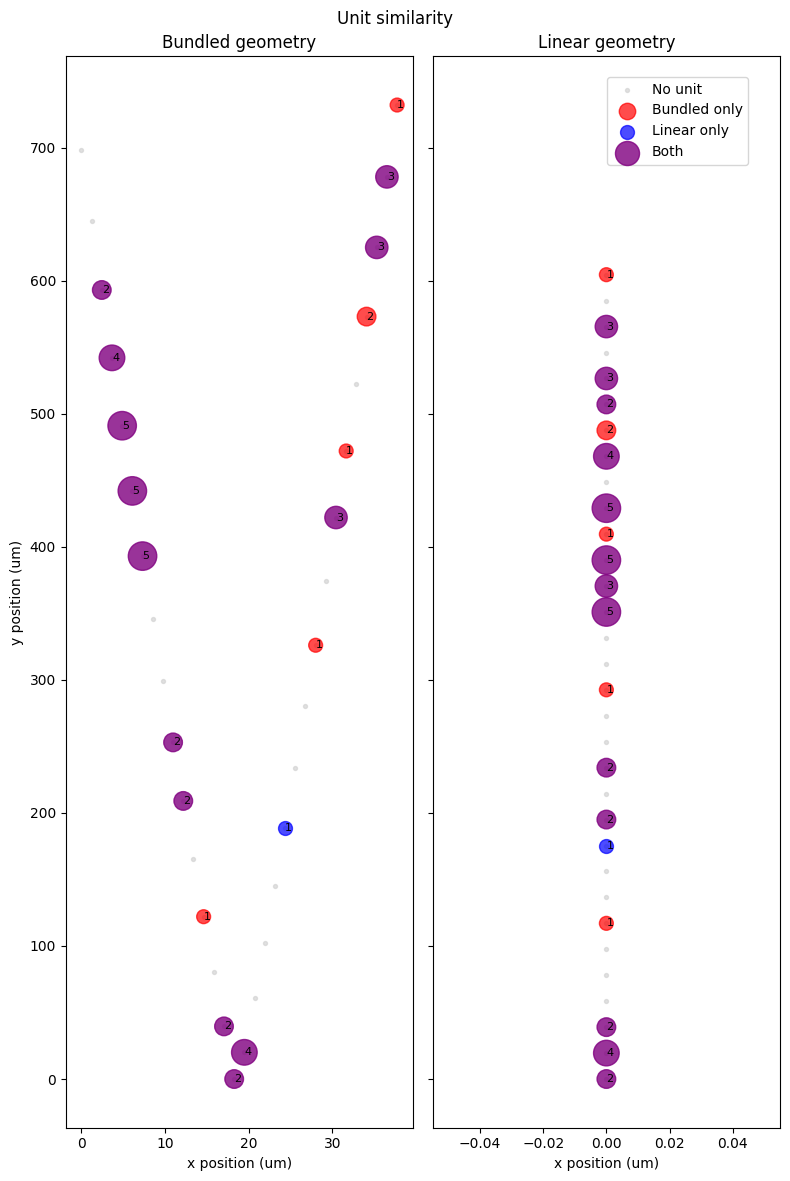

In [4]:
# let's see which units have the same peak channel 

def plot_unit_density_on_geoms(
    bundled_units,
    linear_units,
    chan_map,
    bundled_geom,
    linear_geom,
    size_scale=80,
    base_size=20,
):
    """
    Plot unit density on two probe geometries.

    Red    = bundled units only
    Blue   = linear units only
    Purple = units from both recordings on same channel

    Parameters
    ----------
    bundled_units, linear_units : np.ndarray
        Arrays of shape (n_units, 3):
        [unit_id, peak_chan_id, peak_chan_index]

    chan_map : array-like
        Channel IDs in geometry order.

    bundled_geom, linear_geom : np.ndarray
        Geometry arrays of shape (n_channels, 2), usually x/y positions.

    size_scale : float
        Multiplier for dot size based on number of units.

    base_size : float
        Minimum dot size.
    """

    chan_map = np.asarray(chan_map)
    bundled_units = np.asarray(bundled_units)
    linear_units = np.asarray(linear_units)

    chan_id_to_index = {int(ch): i for i, ch in enumerate(chan_map)}

    bundled_counts = np.zeros(len(chan_map), dtype=int)
    linear_counts = np.zeros(len(chan_map), dtype=int)

    for peak_chan_id in bundled_units[:, 1].astype(int):
        bundled_counts[chan_id_to_index[peak_chan_id]] += 1

    for peak_chan_id in linear_units[:, 1].astype(int):
        linear_counts[chan_id_to_index[peak_chan_id]] += 1

    both = (bundled_counts > 0) & (linear_counts > 0)
    bundled_only = (bundled_counts > 0) & ~both
    linear_only = (linear_counts > 0) & ~both

    total_counts = bundled_counts + linear_counts

    fig, axs = plt.subplots(1, 2, figsize=(8, 12), sharey=True)

    panels = [
        (axs[0], bundled_geom, "Bundled geometry"),
        (axs[1], linear_geom, "Linear geometry"),
    ]

    for ax, geom, title in panels:
        geom = np.asarray(geom)

        ax.scatter(
            geom[:, 0],
            geom[:, 1],
            s=8,
            c="lightgray",
            alpha=0.7,
            label="No unit",
        )

        ax.scatter(
            geom[bundled_only, 0],
            geom[bundled_only, 1],
            s=base_size + size_scale * total_counts[bundled_only],
            c="red",
            alpha=0.7,
            label="Bundled only",
        )

        ax.scatter(
            geom[linear_only, 0],
            geom[linear_only, 1],
            s=base_size + size_scale * total_counts[linear_only],
            c="blue",
            alpha=0.7,
            label="Linear only",
        )

        ax.scatter(
            geom[both, 0],
            geom[both, 1],
            s=base_size + size_scale * total_counts[both],
            c="purple",
            alpha=0.8,
            label="Both",
        )
        
        # label total unit count on non-empty channels
        idx = np.flatnonzero(total_counts > 0)
        for i in idx:
            ax.text(
                geom[i, 0],
                geom[i, 1],
                str(total_counts[i]),
                fontsize=8,
                ha="left",
                va="center",
            )

        ax.set_title(title)
        ax.set_xlabel("x position (um)")

    axs[0].set_ylabel("y position (um)")

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.95, .93))

    fig.suptitle("Unit similarity")
    plt.tight_layout()
    plt.show()

    return {
        "bundled_counts": bundled_counts,
        "linear_counts": linear_counts,
        "total_counts": total_counts,
    }
    
    
counts = plot_unit_density_on_geoms(unit_peak_chans_B, unit_peak_chans_L, siteMap_bundled[32:], siteLoc_bundled[:32], siteLoc_linear)

We see from the above plot that many units from both geom types have the same peak channel. 

We will look closer in whether the two geometries are detecting the same units. 

(3, 4)
[[ 0 13 53  4]
 [ 0 14 53  4]
 [ 1 36 53  4]]


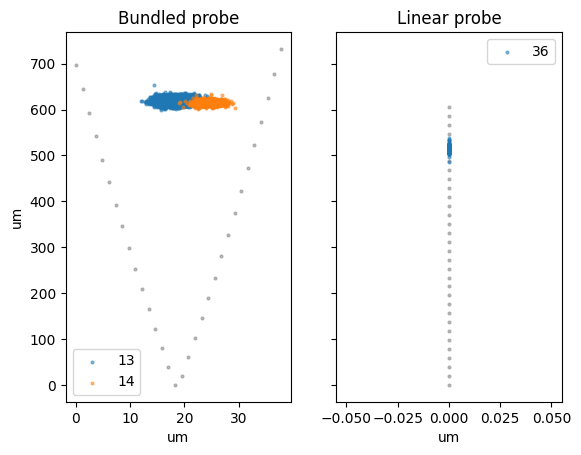

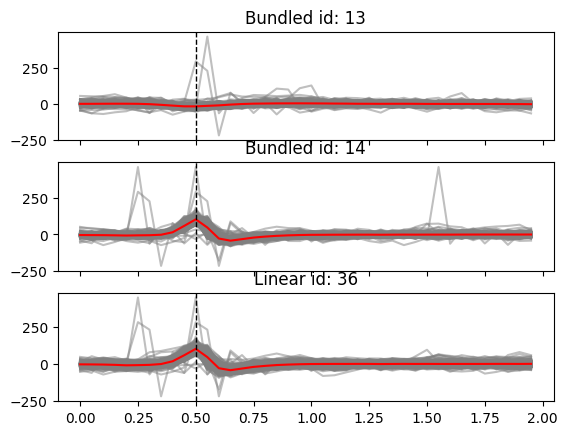

------------------------------------------------------------------------------------------
(3, 4)
[[ 0 11 52  6]
 [ 0 12 52  6]
 [ 1 30 52  6]]


KeyboardInterrupt: 

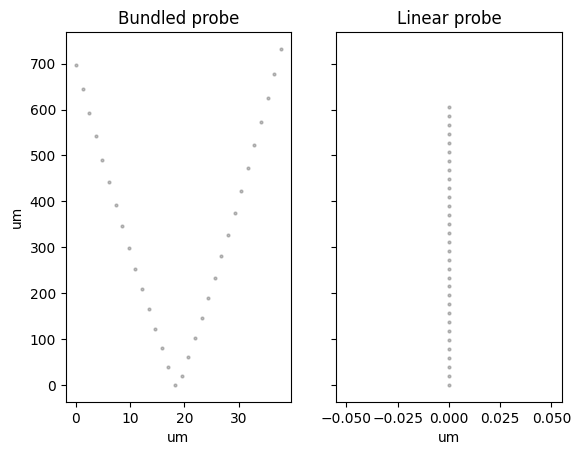

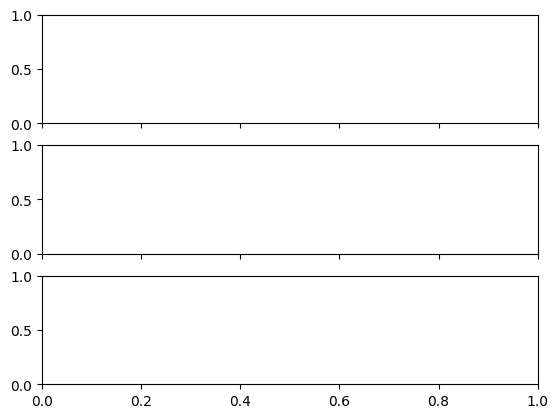

In [39]:
# for each channel with more than one unit, compare the units present based on IBL and also 
# let's first see which units have identical peak channels:

clusters = cluster_units_by_channel_radius(unit_arrays=[unit_peak_chans_B, unit_peak_chans_L], chan_map=siteMap_JR-1, radius=0)
recordings = [recording_B, recording_L]
res_paths = [KILO_B_res_path, KILO_L_res_path]
title = ['Bundled', 'Linear']

no_axes = False
for cluster in clusters:
    cluster = np.array(cluster)
    if cluster.shape[0] > 1:
        fig, axes = plt.subplots(1, 2, sharey=True)
        fig2, axes2 = plt.subplots(len(cluster), 1, sharex=True)
        if len(cluster) == 1:
            no_axes = True

        axes[0].scatter(siteLoc_bundled[:32,0], siteLoc_bundled[:32,1], color="gray", s=4, alpha=0.5)
        axes[1].scatter(siteLoc_linear[:, 0], siteLoc_linear[:,1], color="gray", s=4, alpha=0.5)
        axes[0].set_xlabel("um")
        axes[1].set_xlabel("um")
        axes[0].set_ylabel("um")

        axes[0].set_title("Bundled probe")
        axes[1].set_title("Linear probe")
        print(cluster.shape)
        print(cluster)
        for i, unit in enumerate(cluster):
            # extract the unit data for each cluster 
            data = extract_data_kilosort_results(recordings[unit[0]], res_paths[unit[0]], unit_id=unit[1])
            # do some comparison ! 
            axes[unit[0]].scatter(data["spike_locations"][:, 0], data["spike_locations"][:, 1], s=4, alpha=0.5, label=str(unit[1]))
            t = np.arange(data["spike_waveforms"].shape[1]) / 20000 * 1000

            if no_axes:
                ax = axes2
            else:
                ax = axes2[i]
            ax.set_title(f'{title[unit[0]]} id: {unit[1]}')
            ax.plot(t, data["spike_waveforms"][:1000].T, color="gray", alpha=0.5)
            ax.plot(t, np.mean(data["spike_waveforms"][:1000], axis=0), color="red")
            ax.axvline(0.5, color='black', linestyle='--', linewidth=1)

        axes[0].legend()
        axes[1].legend()
        
        plt.show()
        print("------------------------------------------------------------------------------------------")

In [7]:
# testing bombcell
save_path = os.path.join(KILO_L_res_path, "bombcell")

param = bc.get_default_parameters(
    KILO_L_res_path,
    raw_file=dat_path,
    meta_file=None,
    kilosort_version=4,    
)

#param['probeType'] = ...
param['ephys_sample_rate'] = 20000
param['gain_to_uV'] = 0.195
param['nChannels'] = 32

quality_metrics, param, unit_type, unit_type_string = bc.run_bombcell(KILO_L_res_path, save_path, param)
gui = bc.unit_quality_gui(KILO_L_res_path, quality_metrics=quality_metrics, unit_types=unit_type, param=param, save_path=save_path)


🚀 Starting BombCell quality metrics pipeline...
📁 Processing data from: E:\Viktor_08_sortings\linear_KS4_KS
Results will be saved to: E:\Viktor_08_sortings\linear_KS4_KS\bombcell

Loading ephys data...
Loaded ephys data: 40 units, 626,254 spikes

🔍 Extracting raw waveforms...
Using 32 total channels in recording


0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


IndexError: index 39 is out of bounds for axis 0 with size 31

In [6]:
from pathlib import Path
import numpy as np

ks = Path(KILO_L_res_path)

chan_map = np.load(ks / "channel_map.npy")
templates = np.load(ks / "templates.npy")

print("channel_map shape:", chan_map.shape)
print("channel_map min/max:", chan_map.min(), chan_map.max())
print("templates shape:", templates.shape)

channel_map shape: (30,)
channel_map min/max: 32 63
templates shape: (40, 61, 30)


The two dictionaries contain all the data we need to compare the individual units:

Dict keys:
- unit_peak_chan_index
- spike_times
- spike_amplitudes
- spike_locations
- spike_waveforms

NameError: name 'linear_siteLoc' is not defined

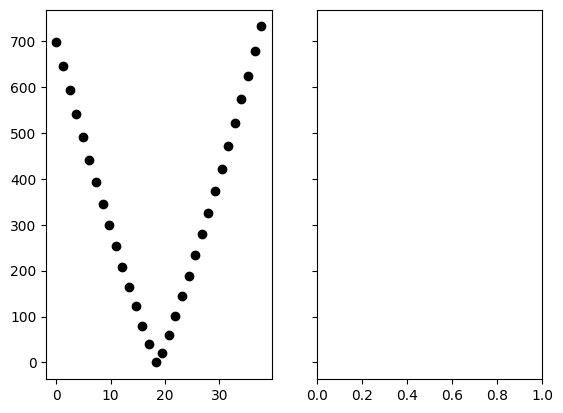

In [9]:
# first plot the LINEAR vs BUNDLED unit locations with the probe 

# load all spikes 
all_spike_positions_B = np.load(os.path.join(KILO_B_res_path, 'spike_positions.npy'))
all_spike_positions_L = np.load(os.path.join(KILO_L_res_path, 'spike_positions.npy'))

fig, axes = plt.subplots(1,2, sharey=True)
axes[0].scatter(siteLoc_JR[:32,0], siteLoc_JR[:32,1], color="black")
axes[1].scatter(linear_siteLoc[:, 0], linear_siteLoc[:,1], color="black")

axes[0].scatter(all_spike_positions_B[:, 0], all_spike_positions_B[:, 1], s=3, alpha=0.5)
axes[1].scatter(all_spike_positions_L[:, 0], all_spike_positions_L[:, 1], s=3, alpha=0.5)

axes[0].set_xlabel("um")
axes[1].set_xlabel("um")
axes[0].set_ylabel("um")

axes[0].set_title(f"Bundled probe: {all_spike_positions_B.shape[0]}")
axes[1].set_title(f"Linear probe: {all_spike_positions_L.shape[0]}")

plt.show()

########################

In [10]:
threshold = 0.8
print("JRCLUST")
JR_corr, JR_isMatch = within_unit_waveform_corr(unit_dict_JR["spike_waveforms"], threshold)
print("KILOSORT")
KILO_corr, KILO_isMatch = within_unit_waveform_corr(unit_dict_KILO_A["spike_waveforms"], threshold)

t_JR = np.arange( unit_dict_JR["spike_waveforms"].shape[1]) / 20000 * 1000
t_KILO = np.arange( unit_dict_KILO_A["spike_waveforms"].shape[1]) / 20000 * 1000

fig, axes = plt.subplots(3, 2, figsize=(10,15))

axes[0,0].hist(JR_corr, bins=50)
axes[0,0].axvline(threshold, color="red", linestyle="--", linewidth=2)
axes[0,0].set_xlabel("Correlation with mean waveform")
axes[0,0].set_ylabel("Number of spikes")
axes[0,0].set_title(f"JRCLUST: waveform-to-mean correlation")

axes[0,1].hist(KILO_corr, bins=50)
axes[0,1].axvline(threshold, color="red", linestyle="--", linewidth=2)
axes[0,1].set_xlabel("Correlation with mean waveform")
axes[0,1].set_ylabel("Number of spikes")
axes[0,1].set_title(f"KILOSORT: waveform-to-mean correlation")


axes[1,0].pie([JR_isMatch.sum(), len(JR_isMatch) - JR_isMatch.sum()],labels=[f"Match r ≥ {threshold}", f"Non-match r < {threshold}"],autopct="%1.1f%%",startangle=90)
axes[1,0].set_title(f"JRCLUST waveform match fraction")

axes[1,1].pie([KILO_isMatch.sum(), len(KILO_isMatch) - KILO_isMatch.sum()],labels=[f"Match r ≥ {threshold}", f"Non-match r < {threshold}"],autopct="%1.1f%%",startangle=90)
axes[1,1].set_title(f"KILOSORT waveform match fraction")

axes[2,0].plot(t_JR, unit_dict_JR["spike_waveforms"][JR_isMatch].mean(axis=0), linewidth=2, label="Matching")
axes[2,0].plot(t_JR, unit_dict_JR["spike_waveforms"][~JR_isMatch].mean(axis=0), linewidth=2, label="Non-matching")
axes[2,0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[2,0].set_xlabel("Time from spike peak (ms)")
axes[2,0].set_ylabel("Amplitude (uV)")
axes[2,0].set_title(f"JRCLUST: mean waveform by match group")
axes[2,0].legend()

axes[2,1].plot(t_KILO, unit_dict_KILO_A["spike_waveforms"][KILO_isMatch].mean(axis=0), linewidth=2, label="Matching")
axes[2,1].plot(t_KILO, unit_dict_KILO_A["spike_waveforms"][~KILO_isMatch].mean(axis=0), linewidth=2, label="Non-matching")
axes[2,1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[2,1].set_xlabel("Time from spike peak (ms)")
axes[2,1].set_ylabel("Amplitude (uV)")
axes[2,1].set_title(f"KILOSORT: mean waveform by match group")
axes[2,1].legend()

plt.show()

JRCLUST


NameError: name 'unit_dict_JR' is not defined

In [ ]:
def corr_1d(a, b):
    a = a - a.mean()
    b = b - b.mean()
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def compare_units(unit_a, unit_b, fs, max_wfs=1000, time_tolerance_ms=0.5):
    out = {}

    # -------------------------
    # 1. Unit-location distance
    # -------------------------
    #loc_a = np.asarray(unit_a["unit_location"])
    #loc_b = np.asarray(unit_b["unit_location"])

    #out["unit_distance_um"] = np.linalg.norm(loc_a - loc_b)

    # -------------------------
    # 2. Spike-location distance distribution
    # -------------------------
    spk_loc_a = np.asarray(unit_a["spike_locations"])
    spk_loc_b = np.asarray(unit_b["spike_locations"])

    n = min(len(spk_loc_a), len(spk_loc_b), max_wfs)

    idx_a = np.random.choice(len(spk_loc_a), n, replace=False)
    idx_b = np.random.choice(len(spk_loc_b), n, replace=False)

    spike_distances = np.linalg.norm(spk_loc_a[idx_a] - spk_loc_b[idx_b], axis=1)
    out["spike_location_distances_um"] = spike_distances

    # -------------------------
    # 3. Mean waveform correlation
    # -------------------------
    wfs_a = np.asarray(unit_a["spike_waveforms"])
    wfs_b = np.asarray(unit_b["spike_waveforms"])

    n_a = min(len(wfs_a), max_wfs)
    n_b = min(len(wfs_b), max_wfs)

    idx_a = np.random.choice(len(wfs_a), n_a, replace=False)
    idx_b = np.random.choice(len(wfs_b), n_b, replace=False)

    mean_a = np.median(wfs_a[idx_a], axis=0)[:40]
    mean_b = np.median(wfs_b[idx_b], axis=0)[:40]

    out["waveform_corr"] = corr_1d(mean_a, mean_b)
    out["mean_waveform_a"] = mean_a
    out["mean_waveform_b"] = mean_b

    # -------------------------
    # 4. Spike-time overlap
    # -------------------------
    tol = int(time_tolerance_ms / 1000 * fs)

    st_a = np.sort(unit_a["spike_times"].astype(np.int64))
    st_b = np.sort(unit_b["spike_times"].astype(np.int64))

    i = j = 0
    matches = 0

    while i < len(st_a) and j < len(st_b):
        dt = st_a[i] - st_b[j]

        if abs(dt) <= tol:
            matches += 1
            i += 1
            j += 1
        elif dt < 0:
            i += 1
        else:
            j += 1

    out["n_spikes_a"] = len(st_a)
    out["n_spikes_b"] = len(st_b)
    out["n_time_matches"] = matches
    out["precision_like"] = matches / len(st_b) if len(st_b) else np.nan
    out["recall_like"] = matches / len(st_a) if len(st_a) else np.nan
    out["agreement_score"] = matches / (len(st_a) + len(st_b) - matches)

    return out

def plot_unit_comparison(result, fs, ms_before=0.5):
    mean_a = result["mean_waveform_a"]
    mean_b = result["mean_waveform_b"]

    time_ms = (np.arange(len(mean_a)) - int(ms_before / 1000 * fs)) / fs * 1000

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Waveforms
    axes[0].plot(time_ms, mean_a, label="Unit A")
    axes[0].plot(time_ms, mean_b, label="Unit B")
    axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[0].set_title(f"Waveform corr = {result['waveform_corr']:.3f}")
    axes[0].set_xlabel("Time from spike peak [ms]")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend()

    # Spike spatial distance histogram
    axes[1].hist(result["spike_location_distances_um"], bins=50)
    #axes[1].axvline(result["unit_distance_um"], linestyle="--", color="red")
    #axes[1].set_title(f"Unit distance = {result['unit_distance_um']:.1f} µm")
    axes[1].set_xlabel("Spike-location distance [µm]")
    axes[1].set_ylabel("Count")

    # Agreement summary
    labels = ["Matched", "A only", "B only"]
    matched = result["n_time_matches"]
    a_only = result["n_spikes_a"] - matched
    b_only = result["n_spikes_b"] - matched

    axes[2].pie(
        [matched, a_only, b_only],
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
    )
    axes[2].set_title(f"Agreement = {result['agreement_score']:.3f}")

    plt.tight_layout()
    plt.show()

In [ ]:
res = compare_units(unit_dict_JR, unit_dict_KILO_A, fs=20000, max_wfs=1000, time_tolerance_ms=0.5)

plot_unit_comparison(res, fs=20000, ms_before=0.5)